In [ ]:
#CSV File Upload
from google.colab import files
uploaded = files.upload()

Saving customer_retail csv file (1).csv to customer_retail csv file (1) (1).csv


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
#Load Dataset
df = pd.read_csv("customer_retail csv file (1).csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
#Select Required Columns
df = df[['Quantity', 'UnitPrice', 'Country']]

df.head()

,Quantity,UnitPrice,Country
0,6,2.55,United Kingdom
1,6,3.39,United Kingdom
2,8,2.75,United Kingdom
3,6,3.39,United Kingdom
4,6,3.39,United Kingdom


In [ ]:
#Handle Missing Values
df.isnull().sum()

#Remove missing values
df = df.dropna()

In [ ]:
#Encode Country Column
encoder = LabelEncoder()

df['Country'] = encoder.fit_transform(df['Country'])

df.head()

,Quantity,UnitPrice,Country
0,6,2.55,36
1,6,3.39,36
2,8,2.75,36
3,6,3.39,36
4,6,3.39,36


In [ ]:
#Create Target Column
df['Target'] = np.where(df['Quantity'] > 10, 1, 0)

df.head()

,Quantity,UnitPrice,Country,Target
0,6,2.55,36,0
1,6,3.39,36,0
2,8,2.75,36,0
3,6,3.39,36,0
4,6,3.39,36,0


In [ ]:
#Define Features and Target
X = df[['Quantity', 'UnitPrice', 'Country']]

y = df['Target']

In [ ]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Logistic Regression
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

print(confusion_matrix(y_test, log_pred))

Logistic Regression Accuracy: 1.0
[[82035     0]
 [    0 26347]]


In [ ]:
#Decision Tree
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 1.0
[[82035     0]
 [    0 26347]]


In [ ]:
#KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

print(confusion_matrix(y_test, knn_pred))

KNN Accuracy: 0.9999907733756528
[[82035     0]
 [    1 26346]]


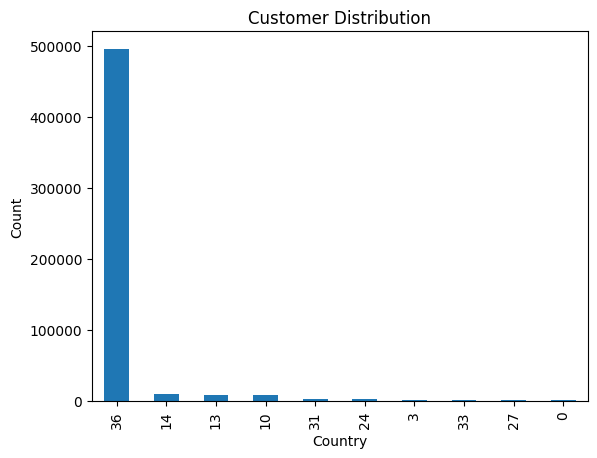

In [ ]:
#Customer Distribution Graph
df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Customer Distribution")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

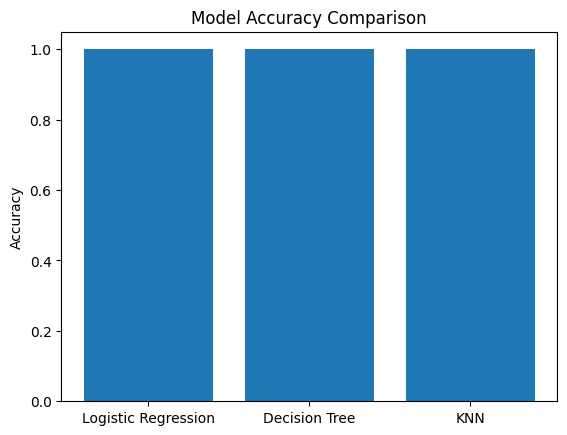

In [ ]:
#Accuracy Comparison Graph
models = ['Logistic Regression', 'Decision Tree', 'KNN']

accuracies = [log_acc, dt_acc, knn_acc]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()